In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import logging

from pathlib import Path

import dotenv

import torch
from torchvision.transforms.v2 import Compose
from torchvision.transforms.v2 import GaussianBlur, Compose

from huggingface_hub import login


from brain_image.data import load_image_from_path
from brain_image.configs import get_device
from brain_image.model import NICEModel
from brain_image.utils import setup

setup()

2025-08-13 14:11:44,352 - INFO - Using device: cuda
2025-08-13 14:11:44,353 - INFO - Using dtype: torch.float16
2025-08-13 14:11:44,353 - INFO - Using directory: /home/gasparyanartur/dev/brain-image-implementation


In [3]:
cp_path = "logs/nice/version_38/checkpoints/nice-epoch=24-val_top1_acc=0.3790.ckpt"
nice_model = NICEModel.load_checkpoint(cp_path, preload_latents=False, undo_compile=True)
device = get_device()
dtype = torch.float16

loader = nice_model.data_module.test_dataloader()
ex_batch = next(iter(loader))
eeg_data = ex_batch["eeg_data"]
img_path = ex_batch["img_path"]

img_latent = nice_model._get_batch_from_cache(img_path, "recon", "sd_highlevel", "test")

/home/gasparyanartur/dev/brain-image-implementation/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 32 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [4]:
from brain_image.reconstruction import ReconstructionPipeline


pipe = ReconstructionPipeline.from_stable_diffusion()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/gasparyanartur/.cache/huggingface/hub/models--lambdalabs--sd-image-variations-diffusers/snapshots/a2a13984e57db80adcc9e3f85d568dcccb9b29fc/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error

In [5]:
images = torch.stack([load_image_from_path(Path(p)) for p in img_path])[:4]
print("Images loaded", images.shape, images.max(), images.min(), images.dtype)


ll_pp_img = pipe.preprocess_low_level_image(images)
pp_img = pipe.preprocess_conditioning_image(images)
print("Images preprocessed", pp_img.shape, pp_img.dtype, pp_img.max(), pp_img.min())
print(
    "Low level images preprocessed",
    ll_pp_img.shape,
    ll_pp_img.dtype,
    ll_pp_img.max(),
    ll_pp_img.min(),
)

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Images preprocessed torch.Size([4, 3, 224, 224]) torch.float16 tensor(2.3477, dtype=torch.float16) tensor(-1.8486, dtype=torch.float16)
Low level images preprocessed torch.Size([4, 3, 512, 512]) torch.float16 tensor(1.0352, dtype=torch.float16) tensor(-0.0629, dtype=torch.float16)


In [14]:
print(str(pipe.image_encoder))

with torch.no_grad():
    out = pipe.image_encoder(pp_img.to(device))
    print("last_hidden_state", out.last_hidden_state.shape)
    print("image_embed", out.image_embeds.shape)

CLIPVisionModelWithProjection(
  (vision_model): CLIPVisionTransformer(
    (embeddings): CLIPVisionEmbeddings(
      (patch_embedding): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (position_embedding): Embedding(257, 1024)
    )
    (pre_layrnorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-23): 24 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (v_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (q_proj): Linear(in_features=1024, out_features=1024, bias=True)
            (out_proj): Linear(in_features=1024, out_features=1024, bias=True)
          )
          (layer_norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=1024, out_featur

2025-08-13 14:11:50,565 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.018651307..1.0556406].
2025-08-13 14:11:50,568 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.024749756..1.0351562].


Shapes (500, 500, 3), (224, 224, 3), (512, 512, 3)
Max 1.0, 1.056, 1.035
Min 0.0, -0.019, -0.025


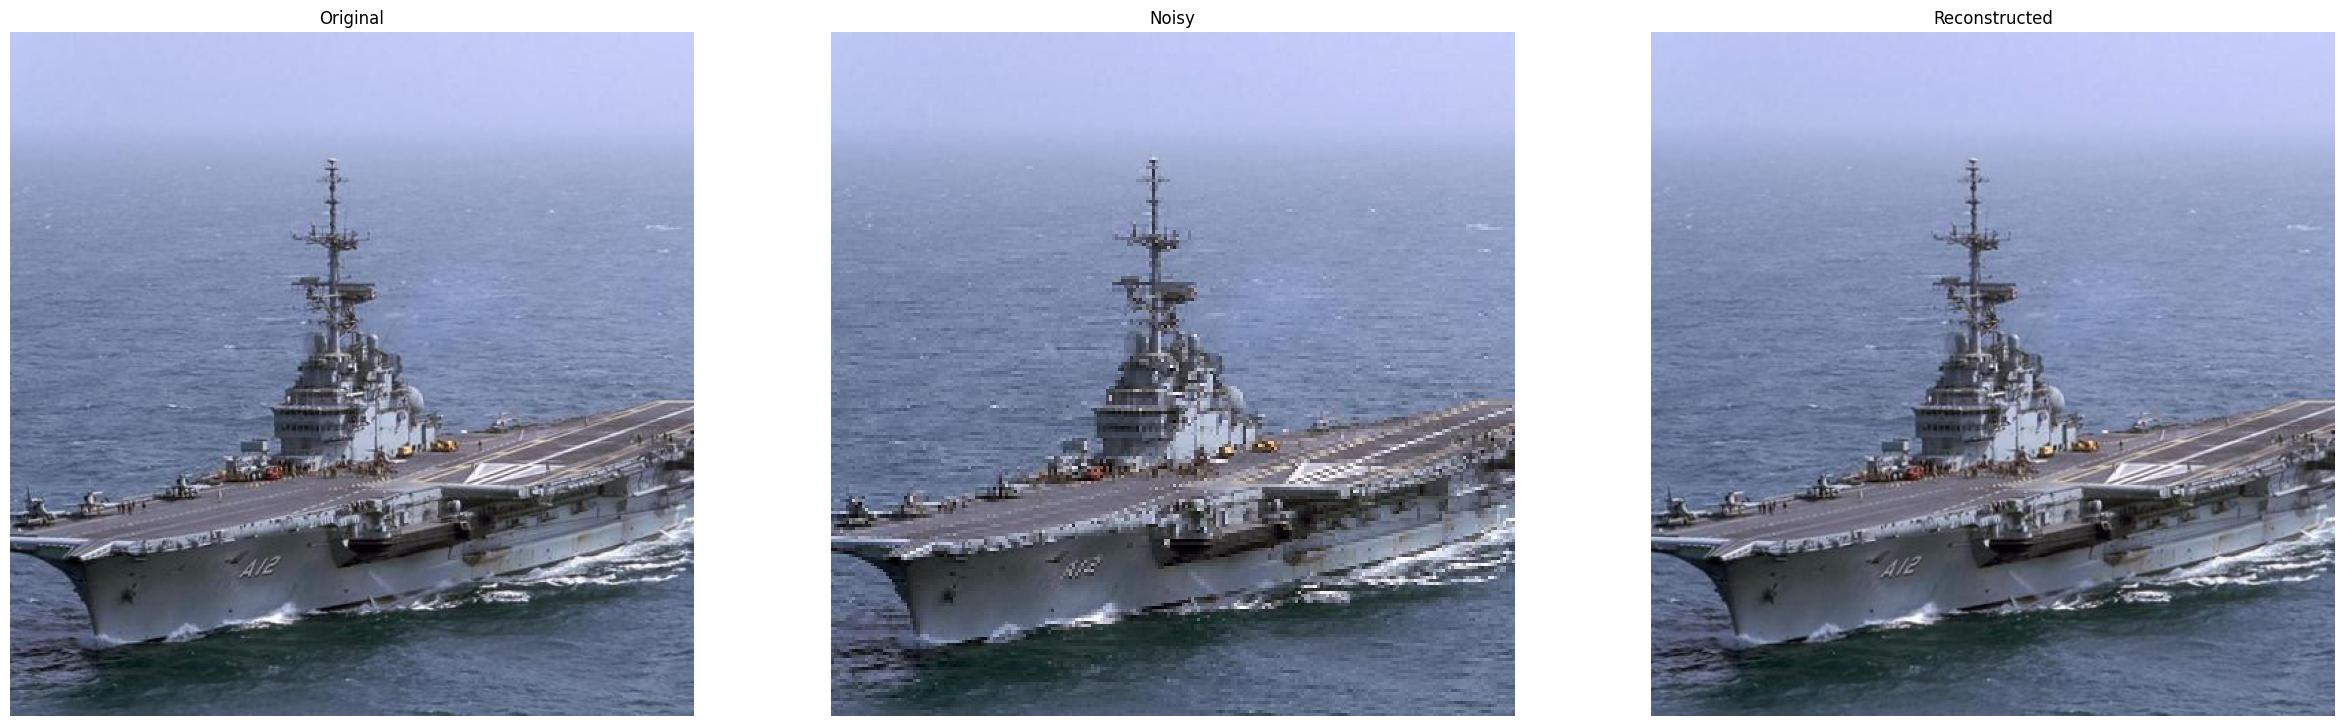

In [7]:
from brain_image.utils import show_image


show_image(
    images[0],
    pp_img[0],
    ll_pp_img[0],
    transforms=["normalize", "unstandardize", "none"],
    verbose=True,
    titles=["Original", "Noisy", "Reconstructed"],
)

Shapes (500, 500, 3), (500, 500, 3)
Max 1.0, 0.988
Min 0.0, 0.094


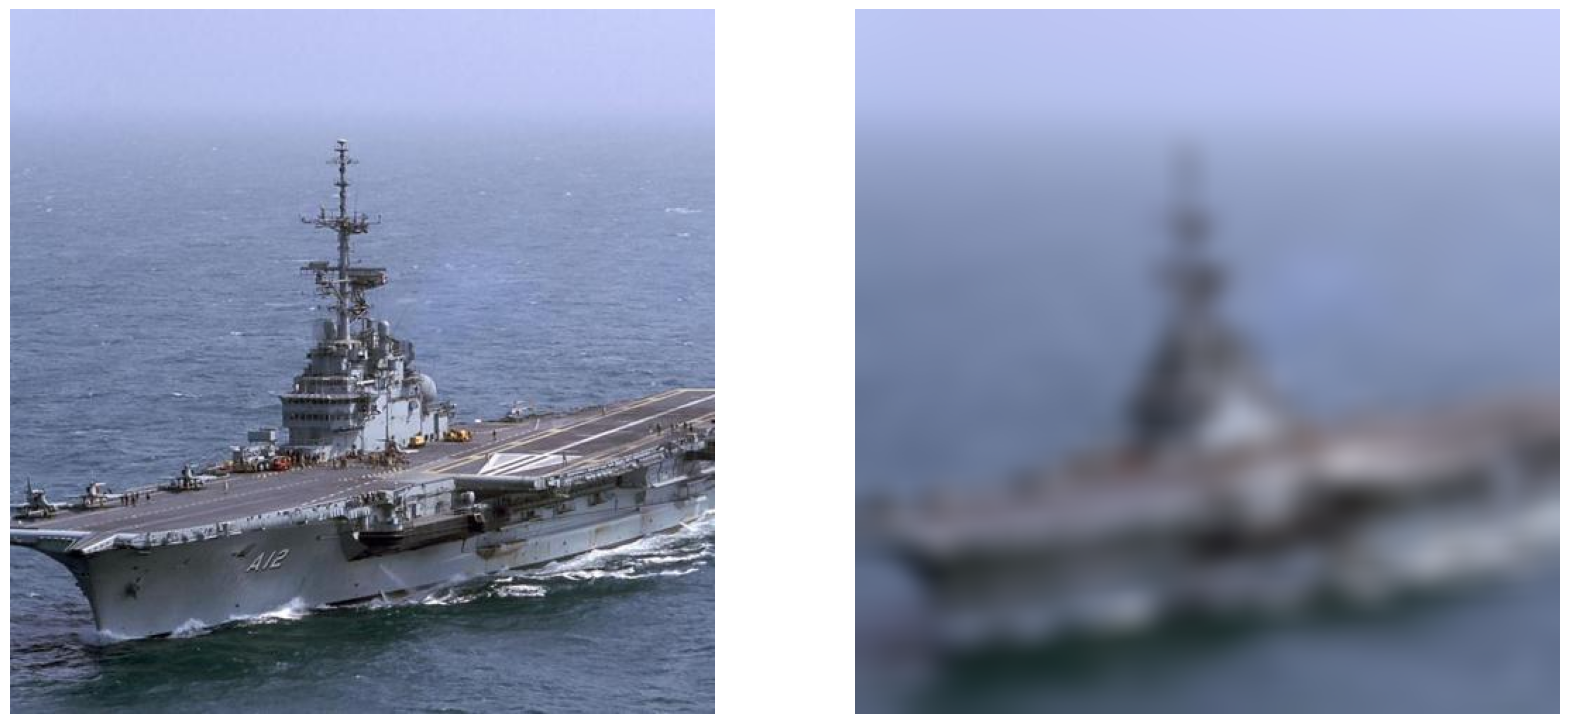

In [8]:
# We create an artificially terrible image for low level

noise_pipe = Compose(
    [
        GaussianBlur(kernel_size=(33, 33), sigma=10.0),
    ]
)

noisy_images = noise_pipe(images)

show_image(
    images[0], noisy_images[0], transforms=["normalize", "normalize"], verbose=True
)

In [9]:
with torch.no_grad():
    print("Images loaded", images.shape, images.max(), images.min(), images.dtype)
    print(
        "Noisy images loaded",
        noisy_images.shape,
        noisy_images.max(),
        noisy_images.min(),
        noisy_images.dtype,
    )

    conditioning_images = images.to(device)
    low_level_images = noisy_images.to(device)

    conditioning_latent = pipe.encode_conditioning_image(conditioning_images)
    print("Conditioning latent:", conditioning_latent.shape, conditioning_latent.dtype, conditioning_latent.max(), conditioning_latent.min())


    low_level_latent = pipe.encode_low_level_image(low_level_images)
    print("Low level latent:", low_level_latent.shape, low_level_latent.dtype, low_level_latent.max(), low_level_latent.min())


    reconstruction = pipe.reconstruct_latents(
        conditioning_latent,
        low_image_latent=low_level_latent,
        noise_strength=0.5,
        guidance_scale=6,
        num_inference_steps=50,
    )

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Noisy images loaded torch.Size([4, 3, 500, 500]) tensor(252, dtype=torch.uint8) tensor(4, dtype=torch.uint8) torch.uint8
Conditioning latent: torch.Size([4, 768]) torch.float16 tensor(8.9609, device='cuda:0', dtype=torch.float16) tensor(-8.2891, device='cuda:0', dtype=torch.float16)
Low level latent: torch.Size([4, 4, 64, 64]) torch.float16 tensor(10.4766, device='cuda:0', dtype=torch.float16) tensor(-15.6328, device='cuda:0', dtype=torch.float16)


In [10]:
with torch.no_grad():
    print("Images loaded", images.shape, images.max(), images.min(), images.dtype)
    print(
        "Noisy images loaded",
        noisy_images.shape,
        noisy_images.max(),
        noisy_images.min(),
        noisy_images.dtype,
    )

    reconstruction = pipe.reconstruct_target(
        images,
        noisy_images,
        noise_strength=0.5,
        guidance_scale=6,
        num_inference_steps=50,
    )

Images loaded torch.Size([4, 3, 500, 500]) tensor(255, dtype=torch.uint8) tensor(0, dtype=torch.uint8) torch.uint8
Noisy images loaded torch.Size([4, 3, 500, 500]) tensor(252, dtype=torch.uint8) tensor(4, dtype=torch.uint8) torch.uint8


2025-08-13 14:12:00,301 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.018651307..1.0556406].


Shapes (224, 224, 3), (512, 512, 3)
Max 1.056, 0.965
Min -0.019, 0.073


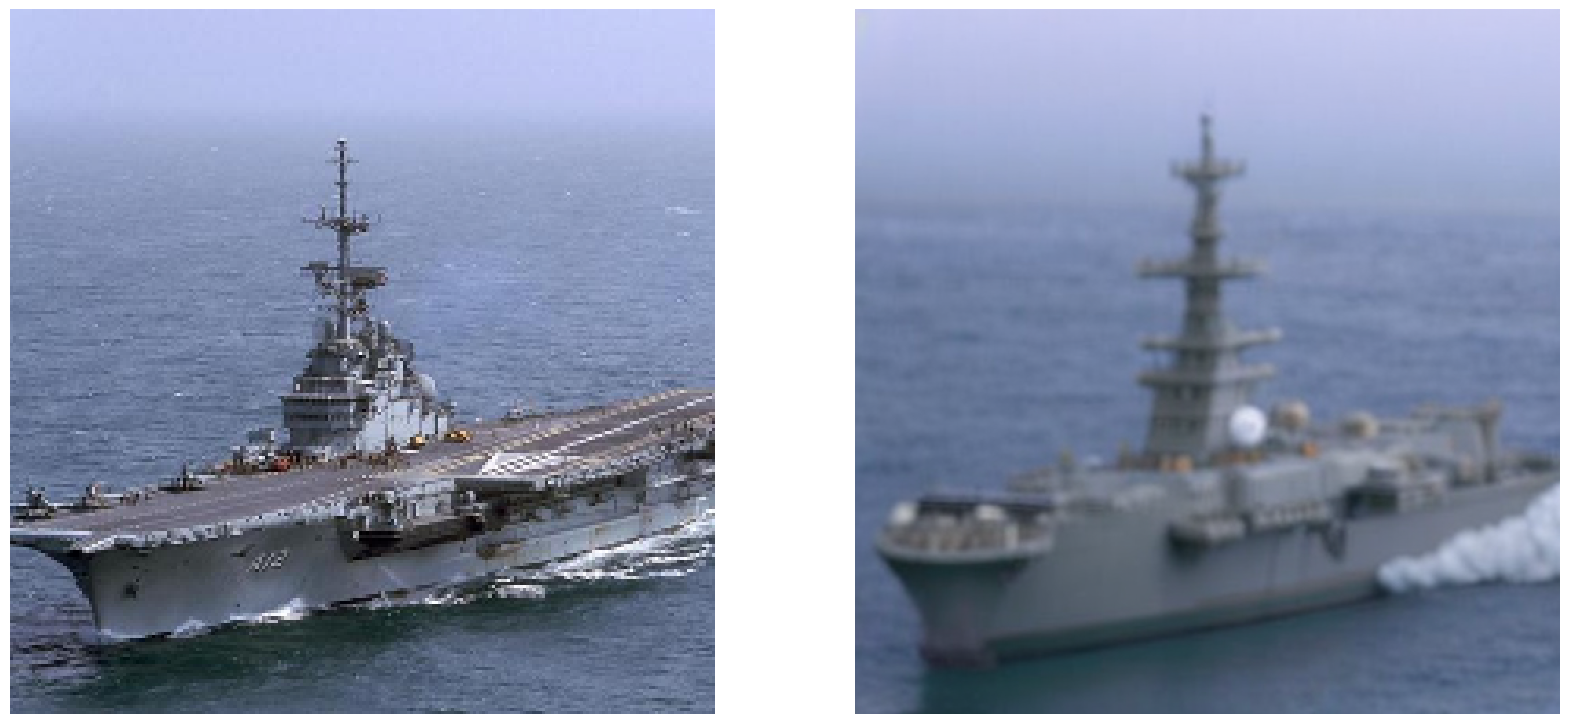

2025-08-13 14:12:00,578 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.048814416..0.95522904].


Shapes (224, 224, 3), (512, 512, 3)
Max 0.955, 0.994
Min -0.049, 0.0


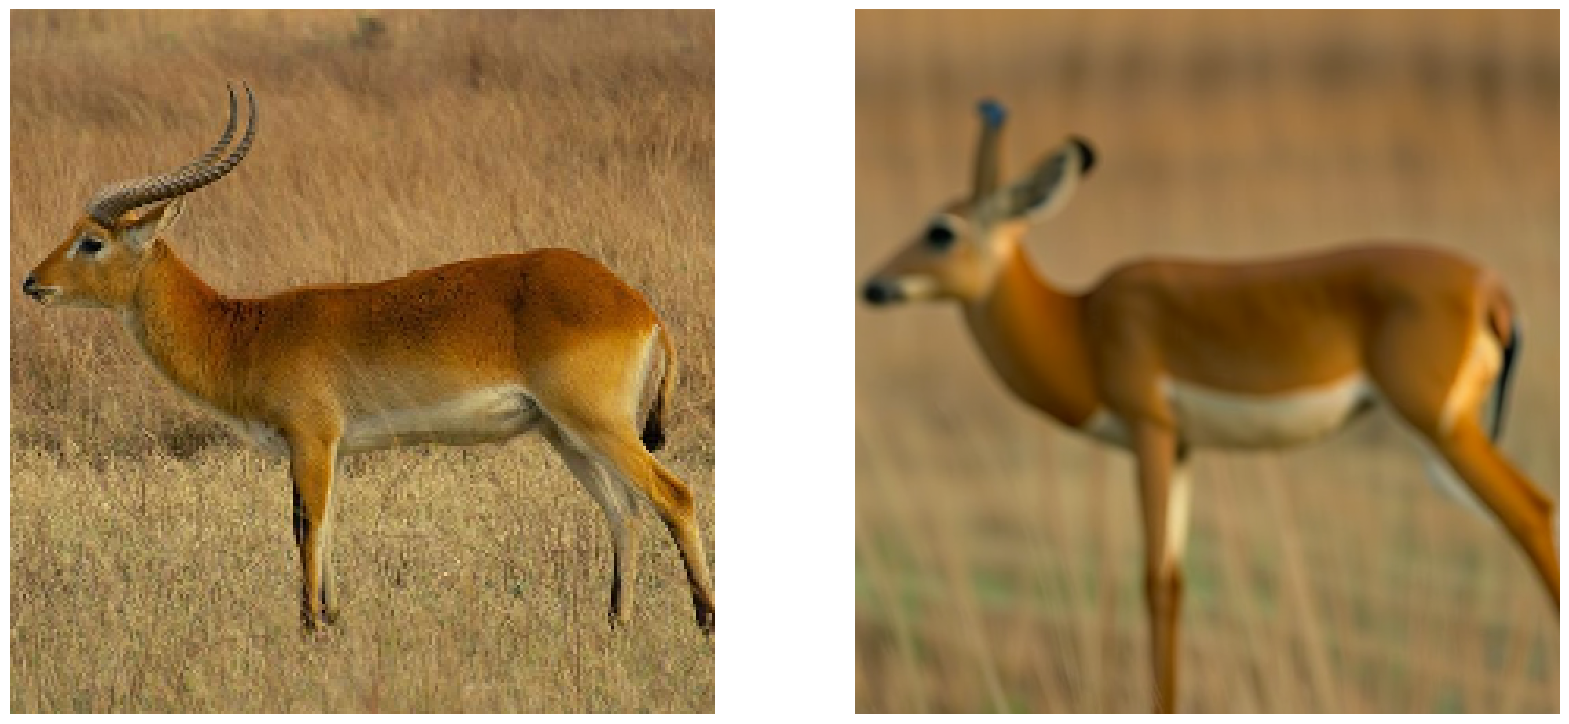

2025-08-13 14:12:00,874 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07843891..1.0234358].


Shapes (224, 224, 3), (512, 512, 3)
Max 1.023, 0.996
Min -0.078, 0.001


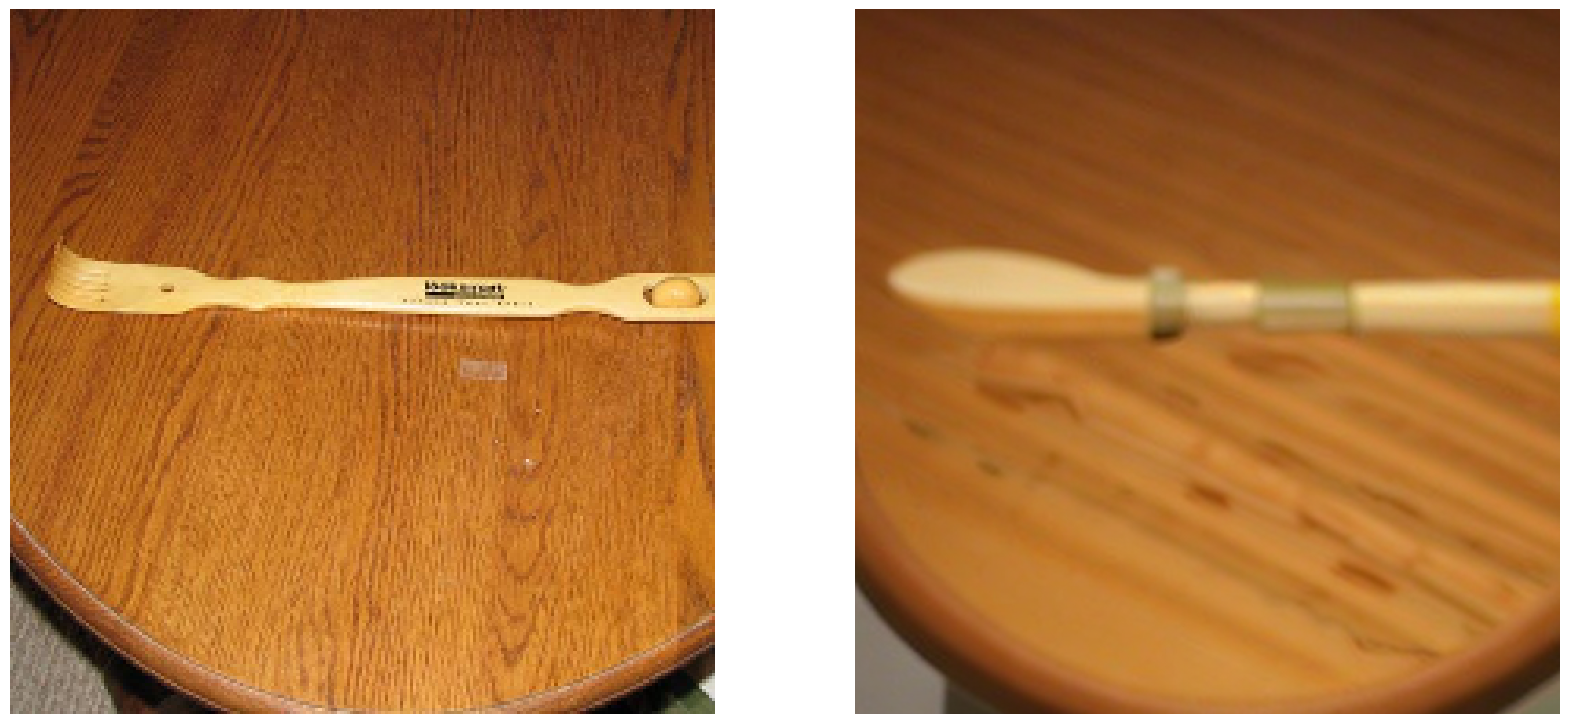

2025-08-13 14:12:01,202 - WARNING - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.037503242..1.0457582].


Shapes (224, 224, 3), (512, 512, 3)
Max 1.046, 0.991
Min -0.038, 0.0


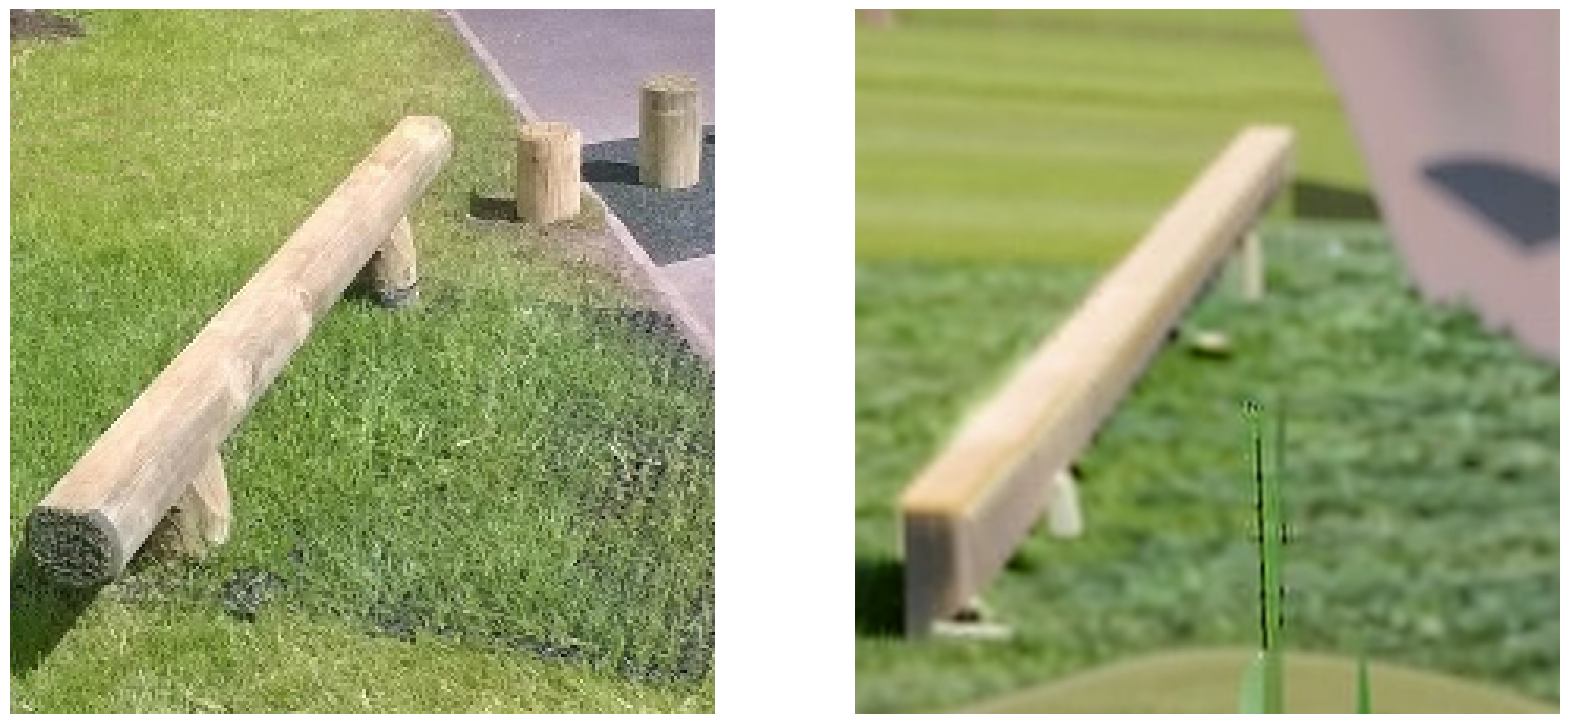

In [11]:
for i in range(4):
    show_image(
        pp_img[i], reconstruction[i], transforms=["unstandardize", "none"], verbose=True
    )

In [12]:
# Sweep over noise strength, guidance scale, and num inference steps

RUN_EXPERIMENTS = False

noise_strengths = [0.2, 0.4, 0.6, 0.8, 1.0]
guidance_scales = [2.5, 5, 7.5, 10]
num_inference_steps = [25, 50, 75]

exp_num = 0

output_path = Path("experiments/reconstruction_target_sweep")
output_path.mkdir(parents=True, exist_ok=True)

if RUN_EXPERIMENTS:
    for noise_strength in noise_strengths:
        for guidance_scale in guidance_scales:
            for num_step in num_inference_steps:
                exp_num += 1
                print(f"================================================")
                print(f"Experiment {exp_num}:")
                print(f"Noise strength: {noise_strength}")
                print(f"Guidance scale: {guidance_scale}")
                print(f"Number of inference steps: {num_step}")
                print(f"================================================")

                with torch.no_grad():
                    reconstruction = pipe.reconstruct_target(
                        images,
                        noisy_images,
                        noise_strength=noise_strength,
                        guidance_scale=guidance_scale,
                        num_inference_steps=num_step,
                    )
                    show_image(
                        images[0],
                        noisy_images[0],
                        reconstruction[0],
                        transforms=["normalize", "normalize", "none"],
                        titles=[
                            "Target (CLIP conditioning)",
                            "Noisy (Low-level image)",
                            "Reconstructed",
                        ],
                        verbose=False,
                        save_path=output_path
                        / f"reconstruction_{exp_num}-ns{noise_strength}-gs{guidance_scale}-is{num_step}.png",
                        show_fig=False,
                        suptitle=f"Noise strength: {noise_strength}, Guidance scale: {guidance_scale}, Number of inference steps: {num_step}",
                    )